In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

try:
    from imblearn.over_sampling import SMOTE
except:
    SMOTE = None

sns.set(style="whitegrid", context="notebook")


In [ ]:
df = pd.read_excel("D:\\DS Assignment\\Random Forest\\Random Forest\\glass.xlsx", sheet_name="glass")

df.head(), df.shape, df.columns.tolist()


(        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
 0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
 1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
 2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
 3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
 4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1,
 (214, 10),
 ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'])

In [3]:
print(df.info())
print("\nMissing values per column:\n", df.isna().sum())
print("\nDescriptive stats:\n"); display(df.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

Missing values per column:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Descriptive stats:



,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518365,0.003037,1.51115,1.516522,1.51768,1.519157,1.53393
Na,214.0,13.407850,0.816604,10.73000,12.907500,13.30000,13.825000,17.38000
Mg,214.0,2.684533,1.442408,0.00000,2.115000,3.48000,3.600000,4.49000
Al,214.0,1.444907,0.499270,0.29000,1.190000,1.36000,1.630000,3.50000
Si,214.0,72.650935,0.774546,69.81000,72.280000,72.79000,73.087500,75.41000
K,214.0,0.497056,0.652192,0.00000,0.122500,0.55500,0.610000,6.21000
Ca,214.0,8.956963,1.423153,5.43000,8.240000,8.60000,9.172500,16.19000
Ba,214.0,0.175047,0.497219,0.00000,0.000000,0.00000,0.000000,3.15000
Fe,214.0,0.057009,0.097439,0.00000,0.000000,0.00000,0.100000,0.51000
Type,214.0,2.780374,2.103739,1.00000,1.000000,2.00000,3.000000,7.00000


Class counts:
 Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

Class proportions:
 Type
2    35.51
1    32.71
7    13.55
3     7.94
5     6.07
6     4.21
Name: proportion, dtype: float64


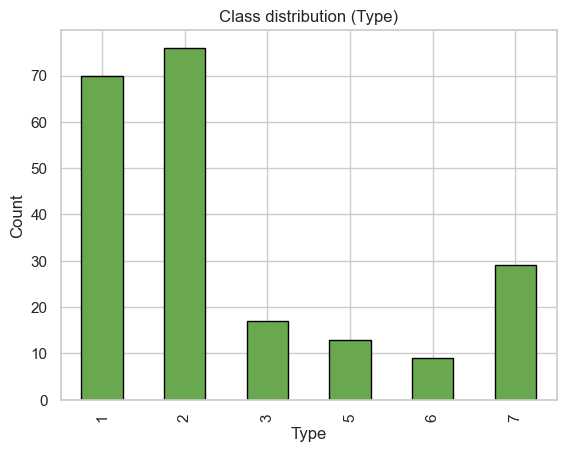

In [4]:
target_col = "Type"
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print("Class counts:\n", y.value_counts().sort_index())
print("\nClass proportions:\n", (y.value_counts(normalize=True)*100).round(2))

# Plot class distribution
ax = y.value_counts().sort_index().plot(kind="bar", color="#6aa84f", edgecolor="black")
ax.set_title("Class distribution (Type)")
ax.set_xlabel("Type")
ax.set_ylabel("Count")
plt.show()


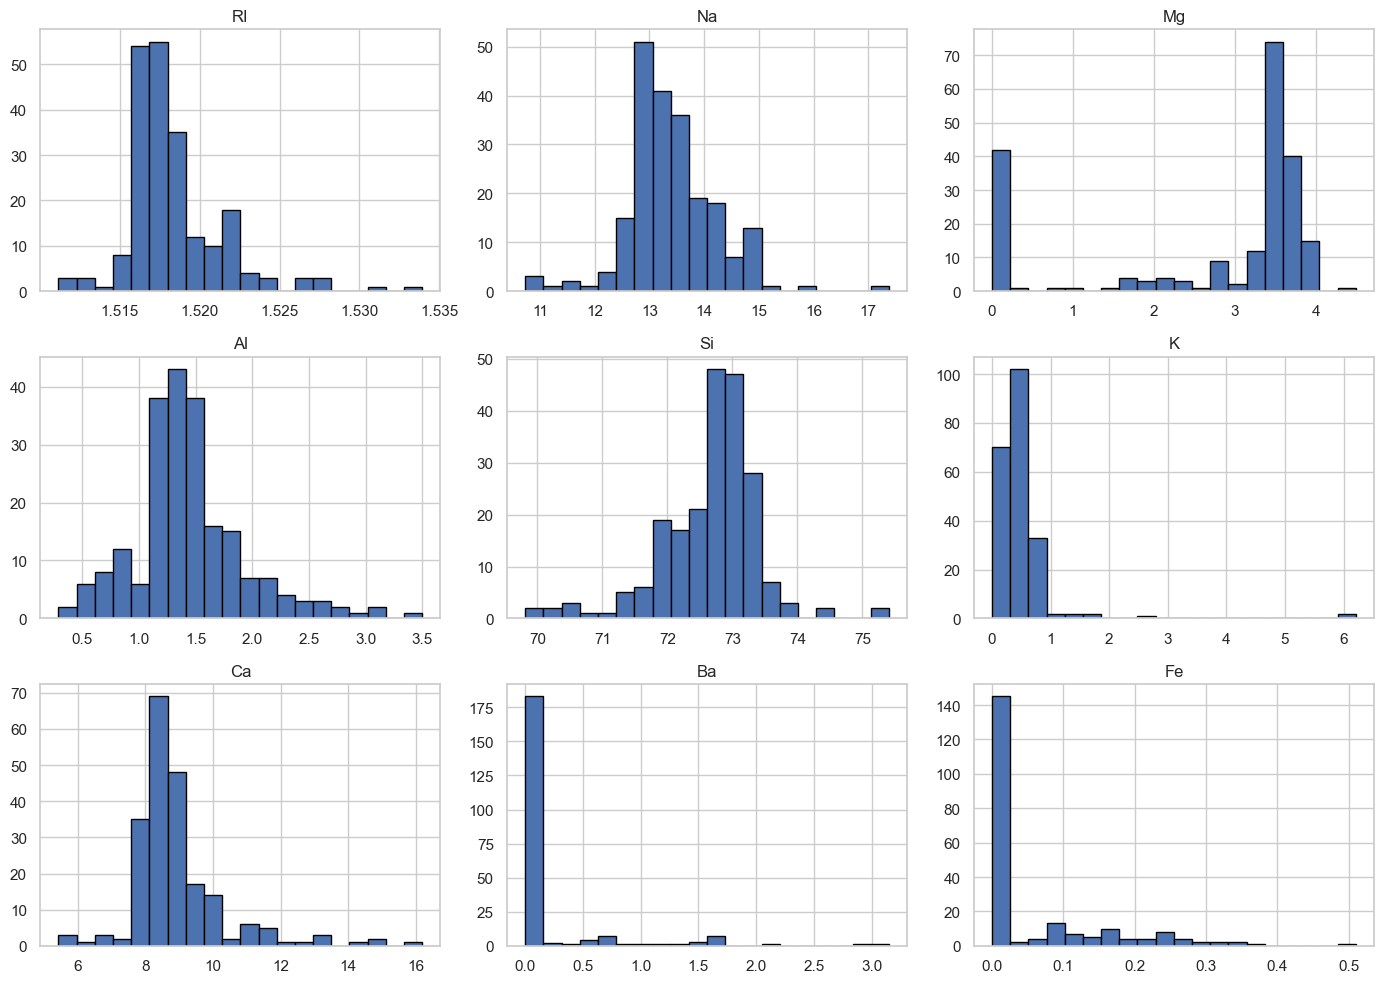

In [5]:
X.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.tight_layout()
plt.show()


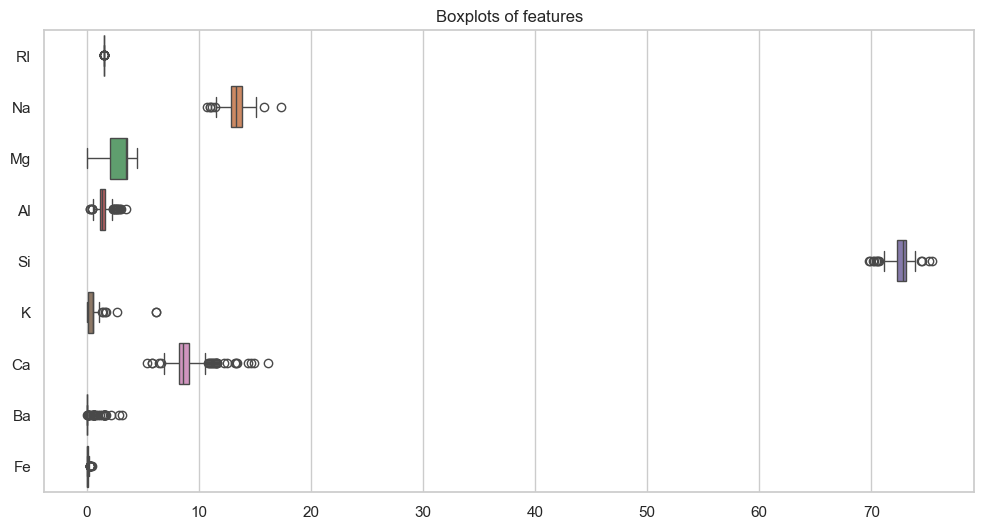

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=X, orient="h")
plt.title("Boxplots of features")
plt.show()


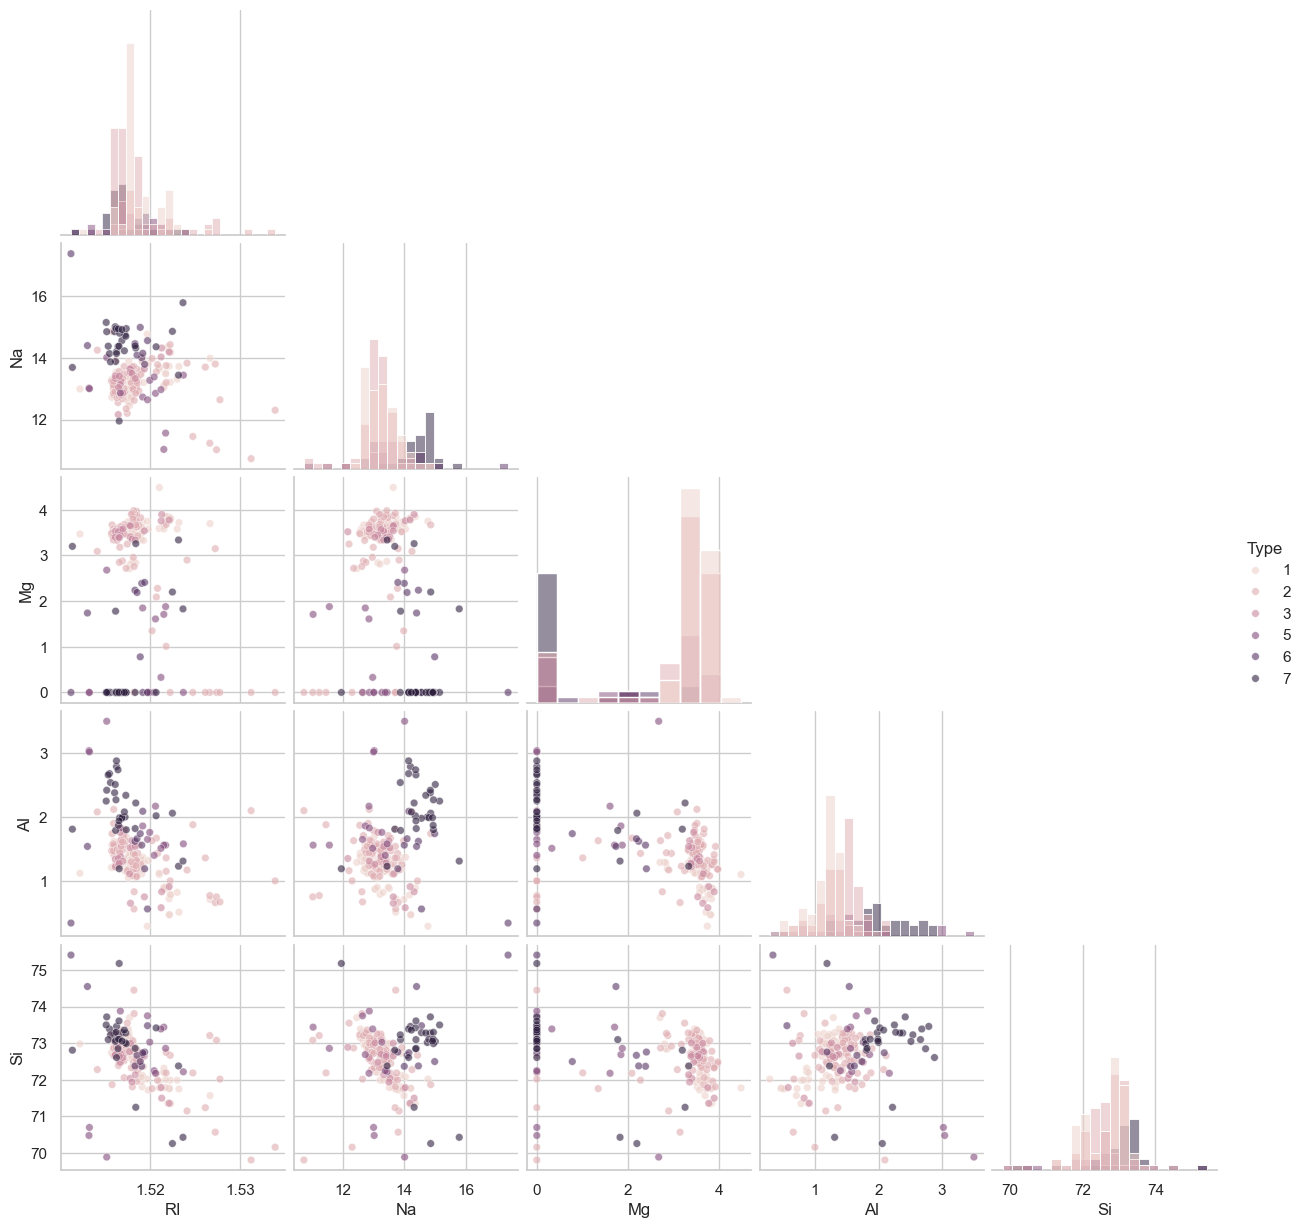

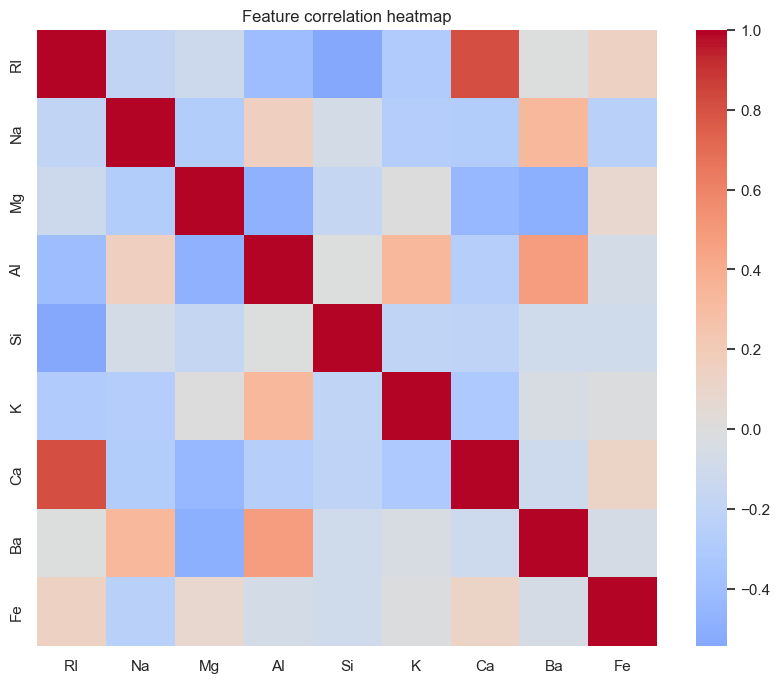

In [ ]:
subset_cols = ["RI", "Na", "Mg", "Al", "Si", "Type"]
sns.pairplot(df[subset_cols], hue="Type", corner=True, diag_kind="hist", plot_kws={"alpha":0.6, "s":30})
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.drop(columns=[target_col]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.show()


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts().sort_index(), y_test.value_counts().sort_index()


((160, 9),
 (54, 9),
 Type
 1    52
 2    57
 3    13
 5    10
 6     7
 7    21
 Name: count, dtype: int64,
 Type
 1    18
 2    19
 3     4
 5     3
 6     2
 7     8
 Name: count, dtype: int64)

In [ ]:
num_features = X.columns.tolist()
preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_features)],
    remainder="drop"
)

def eval_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return acc, pr, rc, f1


In [10]:
rf_baseline = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ))
])

rf_baseline.fit(X_train, y_train)
pred_base = rf_baseline.predict(X_test)

acc_b, pr_b, rc_b, f1_b = eval_metrics(y_test, pred_base)
print("Baseline RF metrics:", acc_b, pr_b, rc_b, f1_b)
print("\nClassification report:\n", classification_report(y_test, pred_base, zero_division=0))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_base))


Baseline RF metrics: 0.8333333333333334 0.8301767676767676 0.8079922027290447 0.7972222222222222

Classification report:
               precision    recall  f1-score   support

           1       0.77      0.94      0.85        18
           2       0.88      0.74      0.80        19
           3       1.00      0.50      0.67         4
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         8

    accuracy                           0.83        54
   macro avg       0.83      0.81      0.80        54
weighted avg       0.85      0.83      0.83        54


Confusion matrix:
 [[17  1  0  0  0  0]
 [ 3 14  0  1  1  0]
 [ 2  0  2  0  0  0]
 [ 0  1  0  2  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  8]]


In [11]:
rf_balanced = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"
    ))
])

rf_balanced.fit(X_train, y_train)
pred_bal = rf_balanced.predict(X_test)

acc_bw, pr_bw, rc_bw, f1_bw = eval_metrics(y_test, pred_bal)
print("Balanced RF metrics:", acc_bw, pr_bw, rc_bw, f1_bw)
print("\nClassification report:\n", classification_report(y_test, pred_bal, zero_division=0))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_bal))


Balanced RF metrics: 0.8518518518518519 0.8869578134284017 0.8514863547758283 0.8472222222222223

Classification report:
               precision    recall  f1-score   support

           1       0.77      0.94      0.85        18
           2       0.88      0.79      0.83        19
           3       1.00      0.50      0.67         4
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.88      0.93         8

    accuracy                           0.85        54
   macro avg       0.89      0.85      0.85        54
weighted avg       0.87      0.85      0.85        54


Confusion matrix:
 [[17  1  0  0  0  0]
 [ 3 15  0  0  1  0]
 [ 2  0  2  0  0  0]
 [ 0  0  0  3  0  0]
 [ 0  0  0  0  2  0]
 [ 0  1  0  0  0  7]]


In [12]:
use_smote = (SMOTE is not None)

if use_smote:
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print("Before SMOTE:", y_train.value_counts().sort_index().to_dict())
    print("After SMOTE:", y_train_sm.value_counts().sort_index().to_dict())

    rf_smote = Pipeline(steps=[
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300, random_state=42, n_jobs=-1
        ))
    ])
    rf_smote.fit(X_train_sm, y_train_sm)
    pred_sm = rf_smote.predict(X_test)

    acc_sm, pr_sm, rc_sm, f1_sm = eval_metrics(y_test, pred_sm)
    print("RF with SMOTE metrics:", acc_sm, pr_sm, rc_sm, f1_sm)
else:
    print("imblearn not available; skipping SMOTE")


Before SMOTE: {1: 52, 2: 57, 3: 13, 5: 10, 6: 7, 7: 21}
After SMOTE: {1: 57, 2: 57, 3: 57, 5: 57, 6: 57, 7: 57}
RF with SMOTE metrics: 0.7962962962962963 0.7334064327485379 0.8246832358674464 0.7676930081341847


In [13]:
bag_dt = Pipeline(steps=[
    ("prep", preprocess),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=300, random_state=42, n_jobs=-1
    ))
])

bag_dt.fit(X_train, y_train)
pred_bag = bag_dt.predict(X_test)


In [ ]:
from sklearn import __version__ as skv
try:
    from packaging.version import parse as V
    PARAM_NAME = "estimator" if V(skv) >= V("1.2") else "base_estimator"
except Exception:
    # Fallback: simple string check (less robust)
    PARAM_NAME = "estimator" if skv.split(".")[0].isdigit() and int(skv.split(".")[0]) >= 1 and int(skv.split(".")[1]) >= 2 else "base_estimator"

print("scikit-learn version:", skv, "| parameter to use:", PARAM_NAME)



scikit-learn version: 1.6.1 | parameter to use: estimator


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

bag_dt = Pipeline(steps=[
    ("prep", preprocess),
    ("model", BaggingClassifier(
        **{PARAM_NAME: DecisionTreeClassifier(random_state=42)},
        n_estimators=300, random_state=42, n_jobs=-1
    ))
])

bag_dt.fit(X_train, y_train)
pred_bag = bag_dt.predict(X_test)

acc_bg, pr_bg, rc_bg, f1_bg = eval_metrics(y_test, pred_bag)
print("Bagging (DT) metrics:", acc_bg, pr_bg, rc_bg, f1_bg)


Bagging (DT) metrics: 0.7777777777777778 0.741898148148148 0.7807017543859649 0.7519337559585239


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

tree_stump = DecisionTreeClassifier(max_depth=2, random_state=42)

ada = Pipeline(steps=[
    ("prep", preprocess),
    ("model", AdaBoostClassifier(
        **{PARAM_NAME: tree_stump},
        n_estimators=300, learning_rate=0.1, random_state=42
    ))
])

ada.fit(X_train, y_train)
pred_ada = ada.predict(X_test)

acc_ad, pr_ad, rc_ad, f1_ad = eval_metrics(y_test, pred_ada)
print("AdaBoost metrics:", acc_ad, pr_ad, rc_ad, f1_ad)


AdaBoost metrics: 0.6851851851851852 0.6457326892109501 0.620004873294347 0.6152421652421652


In [17]:
gbrt = Pipeline(steps=[
    ("prep", preprocess),
    ("model", GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
    ))
])

gbrt.fit(X_train, y_train)
pred_gb = gbrt.predict(X_test)

acc_gb, pr_gb, rc_gb, f1_gb = eval_metrics(y_test, pred_gb)
print("Gradient Boosting metrics:", acc_gb, pr_gb, rc_gb, f1_gb)
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred_gb))


Gradient Boosting metrics: 0.7962962962962963 0.8093567251461988 0.8213937621832358 0.782468798258272

Confusion matrix:
 [[13  3  0  0  1  1]
 [ 2 15  0  0  1  1]
 [ 0  0  3  0  1  0]
 [ 0  1  0  2  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  0  0  8]]


In [18]:
rows = [
    ("RF Baseline", acc_b, pr_b, rc_b, f1_b),
    ("RF Balanced", acc_bw, pr_bw, rc_bw, f1_bw),
]

if 'acc_sm' in locals():
    rows.append(("RF + SMOTE", acc_sm, pr_sm, rc_sm, f1_sm))

rows.extend([
    ("Bagging (DT)", acc_bg, pr_bg, rc_bg, f1_bg),
    ("AdaBoost", acc_ad, pr_ad, rc_ad, f1_ad),
    ("GradientBoosting", acc_gb, pr_gb, rc_gb, f1_gb),
])

results = pd.DataFrame(rows, columns=["Model", "Accuracy", "Macro-Precision", "Macro-Recall", "Macro-F1"])
results.sort_values("Macro-F1", ascending=False)


,Model,Accuracy,Macro-Precision,Macro-Recall,Macro-F1
1,RF Balanced,0.851852,0.886958,0.851486,0.847222
0,RF Baseline,0.833333,0.830177,0.807992,0.797222
5,GradientBoosting,0.796296,0.809357,0.821394,0.782469
2,RF + SMOTE,0.796296,0.733406,0.824683,0.767693
3,Bagging (DT),0.777778,0.741898,0.780702,0.751934
4,AdaBoost,0.685185,0.645733,0.620005,0.615242


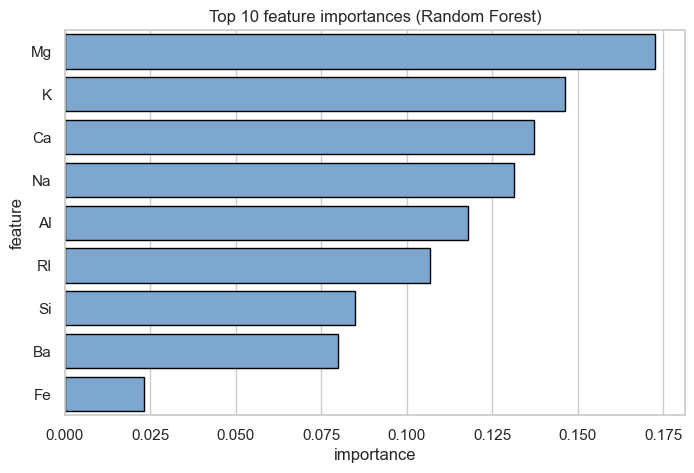

In [ ]:
best_rf_pipe = rf_balanced if (f1_bw >= f1_b) else rf_baseline
best_rf = best_rf_pipe.named_steps["model"]

feat_names = np.array(num_features)
importances = best_rf.feature_importances_

imp = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False)
imp.head(10)
plt.figure(figsize=(8,5))
sns.barplot(data=imp.head(10), x="importance", y="feature", color="#6fa8dc", edgecolor="black")
plt.title("Top 10 feature importances (Random Forest)")
plt.show()
